# BreaKHis Split Audit and Patient Leakage

Before doing any new modelling I wanted to check something that had started to bother me about the way I first split the images. Once I realised the filenames carry patient IDs, I couldn't really trust an image-level split without checking who was leaking across subsets. So this notebook is where I pull the patient codes out, measure the overlap directly, and rebuild the split so each patient lives in only one of train, validation, or test.


## Notebook Purpose

This notebook proves why the BreaKHis workflow must split by patient rather than by image. Because each patient can contribute multiple images, a naive image-level split can leak patient information into train, validation, and test subsets.


## Why This Matters

Patient leakage can make a model appear stronger than it really is. For a medical imaging dissertation, this is a critical methodological risk. The corrected patient-level split is therefore not a minor implementation detail; it is what makes the image-model evaluation credible.


## Build Both Split Strategies

This setup cell creates two competing splits: the initial image-level split and the corrected patient-level split. Comparing them side by side makes the leakage problem measurable rather than theoretical.


In [1]:
from __future__ import annotations

import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()
if (CWD / 'src').exists() and (CWD / 'data').exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / 'src').exists() and (CWD.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent
elif (CWD.parent.parent / 'src').exists() and (CWD.parent.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent.parent
else:
    raise RuntimeError(f'Could not resolve dissertation_project root from {CWD}')

REPO_ROOT = PROJECT_ROOT.parent
OUTPUTS = PROJECT_ROOT / 'outputs'
FIGURES = OUTPUTS / 'figures'
METRICS = OUTPUTS / 'metrics'
REPORTS = OUTPUTS / 'reports'
MODELS = PROJECT_ROOT / 'models'
DATA_ROOT = PROJECT_ROOT / 'data' / 'dataset_cancer_v1' / 'dataset_cancer_v1'
WISCONSIN_ROOT = PROJECT_ROOT / 'notebook_Wisconsin'

for path in [FIGURES, METRICS, REPORTS]:
    path.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print('Project root:', PROJECT_ROOT)
print('Outputs:', OUTPUTS)

from IPython.display import display

from src.breakhis import (
    build_binary_records,
    patient_level_split,
    patient_overlap_examples,
    patient_overlap_report,
    random_image_level_split,
    split_label_summary,
    split_summary,
)

df = build_binary_records(DATA_ROOT)
image_level_split = random_image_level_split(df, random_state=SEED)
corrected_split = patient_level_split(df, random_state=SEED)


Project root: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project
Outputs: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs


## Quantify Patient Overlap

This cell calculates how many patients appear in more than one subset for each split strategy. The expected outcome is that image-level splitting has overlap, while patient-level splitting has zero overlap.


In [2]:
image_level_overlap = patient_overlap_report(image_level_split)
corrected_overlap = patient_overlap_report(corrected_split)
overlap_df = pd.DataFrame(
    [
        {'split_type': 'image_level_initial_attempt', 'subset_pair': key, 'overlap_count': value}
        for key, value in image_level_overlap.items()
    ]
    + [
        {'split_type': 'corrected_patient_level', 'subset_pair': key, 'overlap_count': value}
        for key, value in corrected_overlap.items()
    ]
)
overlap_df.to_csv(REPORTS / 'breakhis_overlap_audit.csv', index=False)
overlap_df


,split_type,subset_pair,overlap_count
0,image_level_initial_attempt,train_val_overlap,82
1,image_level_initial_attempt,train_test_overlap,82
2,image_level_initial_attempt,val_test_overlap,82
3,corrected_patient_level,train_val_overlap,0
4,corrected_patient_level,train_test_overlap,0
5,corrected_patient_level,val_test_overlap,0


## Inspect Concrete Leakage Examples

This cell saves examples of leaked patients from the image-level split. Concrete examples are useful in a dissertation because they make the leakage issue easier to explain and defend.


In [3]:
image_level_examples = patient_overlap_examples(image_level_split, limit=12)
image_level_examples.to_csv(REPORTS / 'breakhis_image_level_overlap_examples.csv', index=False)
image_level_examples.head(12)


,overlap,patient_id
0,train_val,SOB_B_A-14-22549AB
1,train_val,SOB_B_A-14-22549CD
2,train_val,SOB_B_A-14-22549G
3,train_val,SOB_B_A-14-29960CD
4,train_val,SOB_B_F-14-14134
5,train_val,SOB_B_F-14-14134E
6,train_val,SOB_B_F-14-21998CD
7,train_val,SOB_B_F-14-21998EF
8,train_val,SOB_B_F-14-23060AB
9,train_val,SOB_B_F-14-23060CD


## Save Corrected Split Summaries

This cell records both split-level and label-level summaries. It also saves the corrected train, validation, and test CSV files that later notebooks reuse, ensuring that downstream modelling uses the leakage-safe protocol.


In [4]:
image_level_summary = split_summary(image_level_split)
corrected_summary = split_summary(corrected_split)
image_level_label_summary = split_label_summary(image_level_split)
corrected_label_summary = split_label_summary(corrected_split)

image_level_summary.to_csv(REPORTS / 'breakhis_image_level_split_summary.csv', index=False)
corrected_summary.to_csv(REPORTS / 'breakhis_patient_split_summary.csv', index=False)
image_level_label_summary.to_csv(REPORTS / 'breakhis_image_level_split_label_summary.csv', index=False)
corrected_label_summary.to_csv(REPORTS / 'breakhis_patient_split_label_summary.csv', index=False)
corrected_split.train.to_csv(REPORTS / 'breakhis_patient_train_split.csv', index=False)
corrected_split.val.to_csv(REPORTS / 'breakhis_patient_val_split.csv', index=False)
corrected_split.test.to_csv(REPORTS / 'breakhis_patient_test_split.csv', index=False)

display(image_level_summary)
display(corrected_summary)


,subset,images,patients,benign_images,malignant_images
0,train,5536,82,1736,3800
1,val,1186,82,372,814
2,test,1187,82,372,815


,subset,images,patients,benign_images,malignant_images
0,train,5403,57,1597,3806
1,val,1171,12,258,913
2,test,1335,13,625,710


## Visual Leakage Audit

This plot summarizes the overlap counts visually. It is designed as a methods figure: it shows the initial problem and the corrected solution in one place.


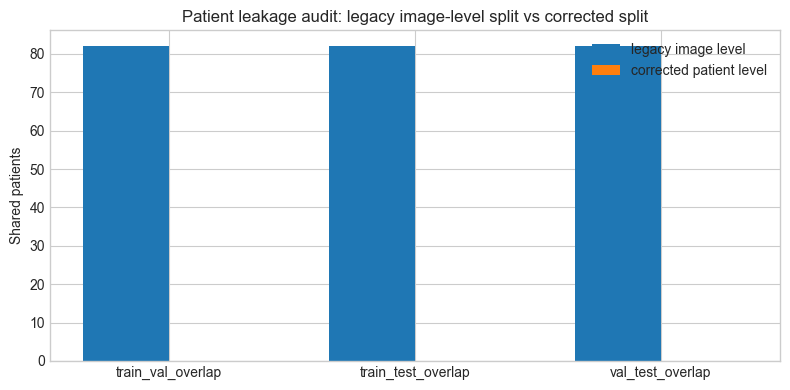

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
for idx, split_type in enumerate(overlap_df['split_type'].unique()):
    subset = overlap_df[overlap_df['split_type'] == split_type]
    ax.bar(
        np.arange(len(subset)) + (idx - 0.5) * 0.35,
        subset['overlap_count'],
        width=0.35,
        label=split_type.replace('_', ' '),
    )
ax.set_xticks(np.arange(len(subset)), subset['subset_pair'])
ax.set_ylabel('Shared patients')
ax.set_title('Patient leakage audit: initial image-level split vs corrected patient-level split')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'breakhis_leakage_audit.png', dpi=300)
plt.show()


## What I found

Once I grouped the files by patient code the overlap was obvious. The same patients were turning up on both sides of the image-level split I started with, which helps explain why that first accuracy looked stronger than it should have. After rebuilding the split at patient level the overlap drops to zero. I have kept the initial image-level version visible here because the contrast matters, but everything after this point uses the corrected patient-level split only.


## How This Notebook Supports The Dissertation

This is one of the key methodology notebooks. It demonstrates that the final image results are evaluated under a stricter and more defensible patient-level split, even if that makes performance lower than a leaked image-level split.
